In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
rice_cammeo_and_osmancik = fetch_ucirepo(id=545) 
  
# data (as pandas dataframes) 
X = rice_cammeo_and_osmancik.data.features 
y = rice_cammeo_and_osmancik.data.targets 
  
# metadata 
print(rice_cammeo_and_osmancik.metadata) 
  
# variable information 
print(rice_cammeo_and_osmancik.variables) 


{'uci_id': 545, 'name': 'Rice (Cammeo and Osmancik)', 'repository_url': 'https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik', 'data_url': 'https://archive.ics.uci.edu/static/public/545/data.csv', 'abstract': "A total of 3810 rice grain's images were taken for the two species, processed and feature inferences were made. 7 morphological features were obtained for each grain of rice.", 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 3810, 'num_features': 7, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5MW4Z', 'creators': [], 'intro_paper': {'ID': 276, 'type': 'NATIVE', 'title': 'Classification of Rice Varieties Using Artificial Intelligence Methods', 'authors': 'Ilkay Cinar, M. Koklu', 'venue': 'International Journal of Intel

In [4]:
X.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024


In [5]:
y.head()

,Class
0,Cammeo
1,Cammeo
2,Cammeo
3,Cammeo
4,Cammeo


In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 208.5 KB


In [7]:
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Class   3810 non-null   str  
dtypes: str(1)
memory usage: 29.9 KB


In [8]:
#check for missing values
X.isnull().sum()

Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
dtype: int64

In [9]:
#check for missing values
y.isnull().sum()

Class    0
dtype: int64

In [10]:
#check duplicates
X.duplicated().sum()

np.int64(0)

In [11]:
#check duplicates
y.duplicated().sum()

np.int64(3808)

## Exploratory data analysis

In [12]:
#evaluate the target column
y.value_counts()

Class   
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64

In [13]:
features = list(X.columns)
features

['Area',
 'Perimeter',
 'Major_Axis_Length',
 'Minor_Axis_Length',
 'Eccentricity',
 'Convex_Area',
 'Extent']

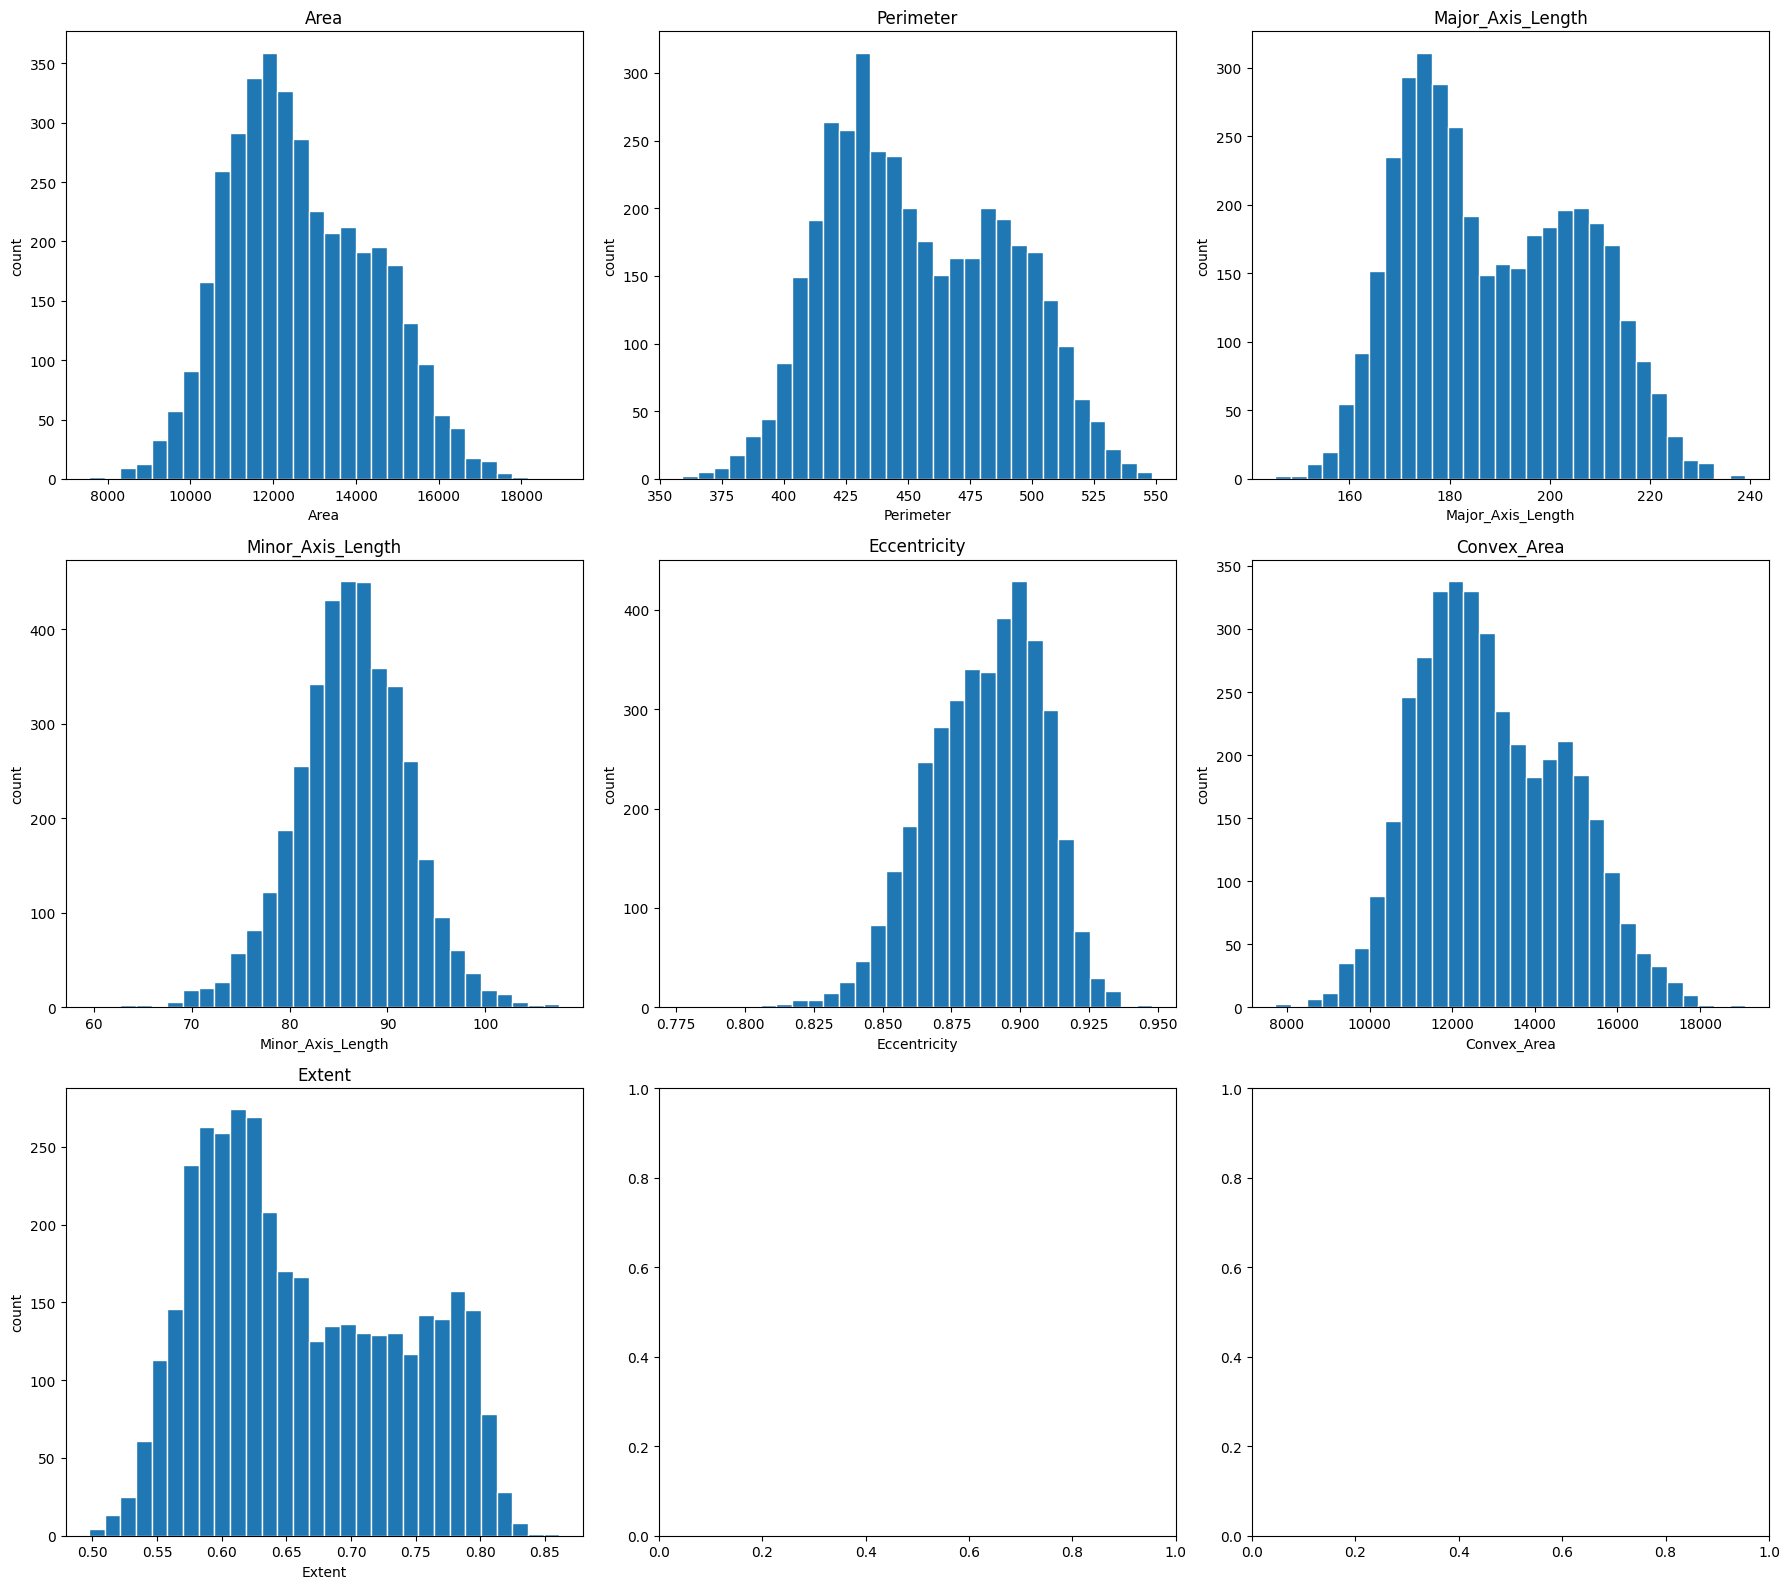

In [14]:
# figure and axes grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(6 * 3, 4 * 4))
axes = axes.flatten()


for i, col in enumerate(features):
    ax = axes[i]
    X[col].plot(kind='hist', ax=ax, bins=30, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()

In [15]:
#lets check for outliers: 
X.kurtosis()

Area                -0.431082
Perimeter           -0.840243
Major_Axis_Length   -0.951802
Minor_Axis_Length    0.562113
Eccentricity         0.071073
Convex_Area         -0.465824
Extent              -1.030101
dtype: float64

In [16]:
df = pd.concat([X, y], axis=1)

In [17]:
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


In [18]:
from IPython.display import display
for col in features:
    print(col)
    df_col = df.groupby('Class')[col].agg(['mean','median', 'std'])
    display(df_col)

Area


,mean,median,std
Class,,,
Cammeo,14162.892025,14212.0,1286.770521
Osmancik,11549.783486,11552.5,1041.908607


Perimeter


,mean,median,std
Class,,,
Cammeo,487.438942,488.179504,22.181518
Osmancik,429.415505,429.239502,20.154394


Major_Axis_Length


...

,mean,median,std
Class,,,
Cammeo,0.901047,0.901759,0.013381
Osmancik,0.876271,0.876206,0.018999


Convex_Area


,mean,median,std
Class,,,
Cammeo,14494.426994,14536.5,1309.418680
Osmancik,11799.585780,11813.5,1062.804346


Extent


,mean,median,std
Class,,,
Cammeo,0.651420,0.634436,0.082197
Osmancik,0.669796,0.652695,0.072340


# feature normalisation

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [20]:
len(X)

3810

In [21]:
#convert Class into one hot encoding


In [22]:
y['Class'] = y['Class'].map({'Cammeo': 1, 'Osmancik': 0})

In [23]:
y.isnull().sum()

Class    0
dtype: int64

In [24]:
y.head()

,Class
0,1
1,1
2,1
3,1
4,1


In [27]:
# train test split
from sklearn.model_selection import train_test_split
X_full_train, X_test, y_full_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [28]:
len(X_full_train)

3048

In [29]:
len(y_full_train)

3048

In [31]:
X_train, X_val, y_train, y_val = train_test_split(X_full_train, y_full_train, test_size=0.25, random_state=42)

In [32]:
len(X_train), len(X_val), len(X_test)

(2286, 762, 762)

In [53]:
len(y_train), len(y_val), len(y_test)

(2286, 762, 762)

In [45]:
from sklearn.ensemble import RandomForestClassifier
#Initialise the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

#Train the model
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)



/home/waltermokwena/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


### Metrics
- Accuracy
- Precision
- Sensitivity
- F1 score

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_score = roc_auc_score(y_val, y_pred)

In [52]:
accuracy, precision, recall, f1, roc_score

(0.9199475065616798,
 0.9053627760252366,
 0.9025157232704403,
 0.9039370078740158,
 0.9174740778514363)

In [62]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, min_samples_leaf=15)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:,1]
roc_score = roc_auc_score(y_val, y_pred)

print(roc_score)
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_score = roc_auc_score(y_val, y_pred)

/home/waltermokwena/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9722753413791149


In [67]:
print(f'accuracy:  {accuracy} \nprecision:  {precision} \nrecall:  {recall} \nf1: {f1} \nroc_score:  {roc_score}')

accuracy:  0.9199475065616798 
precision:  0.9053627760252366 
recall:  0.9025157232704403 
f1: 0.9039370078740158 
roc_score:  0.9722753413791149
